# Notebook 2: Sentiment Classification – Fine-tuning BERT
**Technique:** Transformer-based Model · Transfer Learning · Fine-tuning  
**Model:** `bert-base-uncased` → fine-tuned on IMDb 50K  
**Task:** Binary classification — Positive / Negative

---

In [1]:
import sys
!{sys.executable} -m pip check

No broken requirements found.


In [2]:
try:
    from transformers.models.bert.modeling_bert import BertForSequenceClassification
    print("OK")
except Exception as e:
    print(type(e).__name__, ":", e)

OK


## 2.1 Setup & Load Data

In [3]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from torch.utils.data import Dataset, DataLoader
from transformers import (
    DistilBertTokenizer, 
    DistilBertForSequenceClassification,
    AdamW,
    get_linear_schedule_with_warmup
)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    roc_auc_score,
    roc_curve
)
from tqdm import tqdm

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# Load preprocessed splits from Notebook 1
train_df = pd.read_csv('../data/train.csv')
val_df   = pd.read_csv('../data/val.csv')
test_df  = pd.read_csv('../data/test.csv')

print(f'\nTrain: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}')

Using device: cpu

Train: 35,000 | Val: 7,500 | Test: 7,500


## 2.2 BERT Tokenizer & Dataset Class

In [4]:
# Load the pre-trained BERT tokenizer
MODEL_NAME = 'distilbert-base-uncased' #'bert-base-uncased'
tokenizer = DistilBertTokenizer.from_pretrained(MODEL_NAME)
MAX_LEN = 128  # BERT max is 512; 256 is faster and works well for reviews

class IMDbDataset(Dataset):
    """Custom PyTorch Dataset for IMDb reviews."""
    def __init__(self, reviews, labels, tokenizer, max_len):
        self.reviews   = reviews.reset_index(drop=True)
        self.labels    = labels.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.reviews)

    def __getitem__(self, idx):
        review = str(self.reviews[idx])
        label  = int(self.labels[idx])

        # Tokenize: adds [CLS] and [SEP], pads/truncates to max_len
        encoding = self.tokenizer.encode_plus(
            review,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label':          torch.tensor(label, dtype=torch.long)
        }

# Create dataset objects
BATCH_SIZE = 16

train_dataset = IMDbDataset(train_df['cleaned_review'], train_df['label'], tokenizer, MAX_LEN)
val_dataset   = IMDbDataset(val_df['cleaned_review'],   val_df['label'],   tokenizer, MAX_LEN)
test_dataset  = IMDbDataset(test_df['cleaned_review'],  test_df['label'],  tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'✅ Datasets ready | Batch size: {BATCH_SIZE}')
print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

# Show one tokenized sample
sample = train_dataset[0]
print(f'\nSample tokens (first 20): {sample["input_ids"][:20]}')
print(f'Label: {sample["label"]}')

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

✅ Datasets ready | Batch size: 16
Train batches: 2188 | Val batches: 469

Sample tokens (first 20): tensor([  101,  2215,  2156,  2995, 10874,  9278,  2025,  2472, 11167,  6978,
         2987,  2102,  3444,  2058, 18908,  2075,  2058,  4502,  3593,  2694])
Label: 1


## 2.3 Load Pre-trained BERT Model – Transfer Learning

In [5]:
# Load BERT with a classification head (2 output classes: pos/neg)
# This is TRANSFER LEARNING: we take a model pre-trained on BooksCorpus + Wikipedia
# and fine-tune it on our domain-specific IMDb data

model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    output_attentions=False,
    output_hidden_states=False
)
model = model.to(device)

# Count trainable parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters:     {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

# Set up optimizer and scheduler
EPOCHS = 3
optimizer = AdamW(model.parameters(), lr=2e-5, eps=1e-8, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)
print(f'\n✅ Model ready | Epochs: {EPOCHS} | Total steps: {total_steps:,}')

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Total parameters:     66,955,010
Trainable parameters: 66,955,010

✅ Model ready | Epochs: 3 | Total steps: 6,564


## 2.4 Training & Validation Loop

In [6]:
def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for batch in tqdm(loader, desc='Training'):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        logits = outputs.logits

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / len(loader), correct / total

def eval_epoch(model, loader, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in tqdm(loader, desc='Evaluating'):
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)

            outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            logits = outputs.logits

            total_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return total_loss / len(loader), correct / total, all_preds, all_labels

# === TRAINING LOOP ===
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0

for epoch in range(1, EPOCHS + 1):
    print(f'\n=== Epoch {epoch}/{EPOCHS} ===')
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, device)
    val_loss, val_acc, _, _ = eval_epoch(model, val_loader, device)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}')
    print(f'Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}')

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        model.save_pretrained('../models/bert_sentiment')
        tokenizer.save_pretrained('../models/bert_sentiment')
        print(f'💾 Best model saved (val_acc={val_acc:.4f})')

print(f'\n✅ Training complete! Best Val Accuracy: {best_val_acc:.4f}')


=== Epoch 1/3 ===


Evaluating: 100%|██████████| 469/469 [13:53<00:00,  1.78s/it]


Train Loss: 0.3684 | Train Acc: 0.8318
Val   Loss: 0.2819 | Val   Acc: 0.8828
💾 Best model saved (val_acc=0.8828)

=== Epoch 2/3 ===


Evaluating: 100%|██████████| 469/469 [12:05<00:00,  1.55s/it]


Train Loss: 0.2212 | Train Acc: 0.9185
Val   Loss: 0.2854 | Val   Acc: 0.8956
💾 Best model saved (val_acc=0.8956)

=== Epoch 3/3 ===


Evaluating: 100%|██████████| 469/469 [12:13<00:00,  1.56s/it]


Train Loss: 0.1442 | Train Acc: 0.9565
Val   Loss: 0.3761 | Val   Acc: 0.8976
💾 Best model saved (val_acc=0.8976)

✅ Training complete! Best Val Accuracy: 0.8976


## 2.5 Plot Training Curves

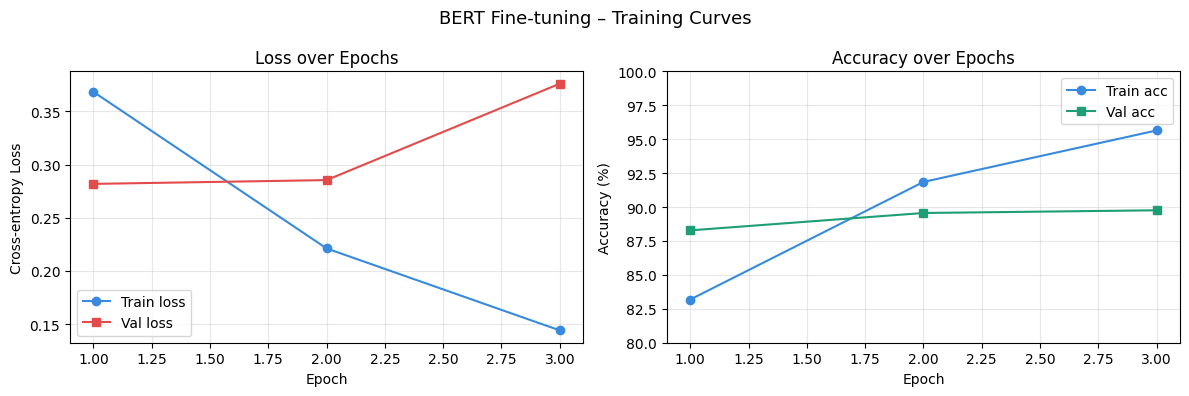

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_range = range(1, EPOCHS + 1)

axes[0].plot(epochs_range, history['train_loss'], 'o-', color='#378ADD', label='Train loss')
axes[0].plot(epochs_range, history['val_loss'],   's-', color='#E24B4A', label='Val loss')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-entropy Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, [a*100 for a in history['train_acc']], 'o-', color='#378ADD', label='Train acc')
axes[1].plot(epochs_range, [a*100 for a in history['val_acc']],   's-', color='#1D9E75', label='Val acc')
axes[1].set_title('Accuracy over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_ylim(80, 100)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('BERT Fine-tuning – Training Curves', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/04_bert_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.6 Evaluation on Test Set

In [8]:
# Load best saved model
from transformers import DistilBertForSequenceClassification, BertTokenizer
model = DistilBertForSequenceClassification.from_pretrained('../models/bert_sentiment').to(device)

_, test_acc, y_pred, y_true = eval_epoch(model, test_loader, device) 

print('=== Test Set Performance ===')
print(f'Accuracy : {accuracy_score(y_true, y_pred):.4f}')
print(f'F1 Score : {f1_score(y_true, y_pred):.4f}')
print(f'\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=['Negative', 'Positive']))

Evaluating: 100%|██████████| 469/469 [11:45<00:00,  1.50s/it]

=== Test Set Performance ===
Accuracy : 0.8983
F1 Score : 0.8972

Classification Report:
              precision    recall  f1-score   support

    Negative       0.89      0.91      0.90      3750
    Positive       0.91      0.89      0.90      3750

    accuracy                           0.90      7500
   macro avg       0.90      0.90      0.90      7500
weighted avg       0.90      0.90      0.90      7500



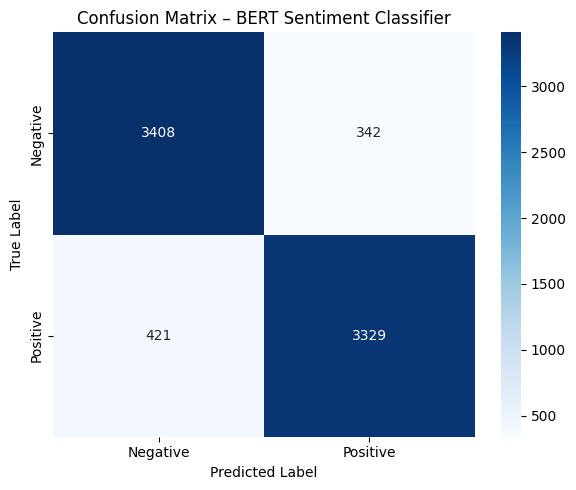

In [10]:
# Confusion Matrix
import seaborn as sns

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_true, y_pred)
sns_hm = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                     xticklabels=['Negative', 'Positive'],
                     yticklabels=['Negative', 'Positive'], ax=ax)
ax.set_title('Confusion Matrix – BERT Sentiment Classifier', fontsize=12)
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('../outputs/05_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Inference function – use this in the demo app
def predict_sentiment(text, model, tokenizer, device, max_len=256):
    """Predict sentiment for a single review."""
    model.eval()
    encoding = tokenizer.encode_plus(
        text,
        add_special_tokens=True,
        max_length=max_len,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )
    input_ids      = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids, attention_mask=attention_mask)
        probs = torch.softmax(outputs.logits, dim=1).cpu().numpy()[0]

    label = 'Positive' if probs[1] > 0.5 else 'Negative'
    return {'label': label, 'positive_prob': round(float(probs[1]), 4), 'negative_prob': round(float(probs[0]), 4)}

# Demo
test_reviews = [
    "This movie was absolutely fantastic! The acting was superb and the plot kept me on the edge of my seat.",
    "Terrible waste of time. The story made no sense and the acting was wooden.",
    "An average film. Some good moments but also quite boring in the middle."
]
print('=== Inference Demo ===')
for review in test_reviews:
    result = predict_sentiment(review, model, tokenizer, device)
    print(f'Review: {review[:70]}...')
    print(f'  → {result["label"]} (pos: {result["positive_prob"]:.2%} | neg: {result["negative_prob"]:.2%})\n')

=== Inference Demo ===
Review: This movie was absolutely fantastic! The acting was superb and the plo...
  → Positive (pos: 98.92% | neg: 1.08%)

Review: Terrible waste of time. The story made no sense and the acting was woo...
  → Negative (pos: 0.22% | neg: 99.78%)

Review: An average film. Some good moments but also quite boring in the middle...
  → Negative (pos: 0.32% | neg: 99.68%)

